In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [10]:
sns.set_theme(style="whitegrid")

In [11]:
df = pd.read_csv('../data/final/final_data.csv')

In [12]:
df.shape

(4595, 22)

In [13]:
df.columns

Index(['LOG_LIQ', 'EDUC', 'LOG_INCOME', 'HHOUSES', 'AGE', 'FINLIT', 'EMERGSAV',
       'KIDS', 'MARRIED', 'OCCAT1', 'YESFINRISK', 'LOG_DEBT', 'SPENDMOR',
       'LATE', 'LOG_RET_ASSETS', 'AGE_GROUP', 'RET_MULTIPLIER',
       'INCOME_RAW_EST', 'RET_ASSETS_RAW_EST', 'DEBT_RAW_EST',
       'RET_READY_THRESHOLD', 'RET_READY'],
      dtype='str')

Visualization 1

In [14]:
# Check class counts and percentages
ret_ready_counts = (
    df["RET_READY"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not Ready", 1: "Ready"})
)

ret_ready_percent = ret_ready_counts / ret_ready_counts.sum() * 100
ret_ready_percent

RET_READY
Not Ready    65.223069
Ready        34.776931
Name: count, dtype: float64

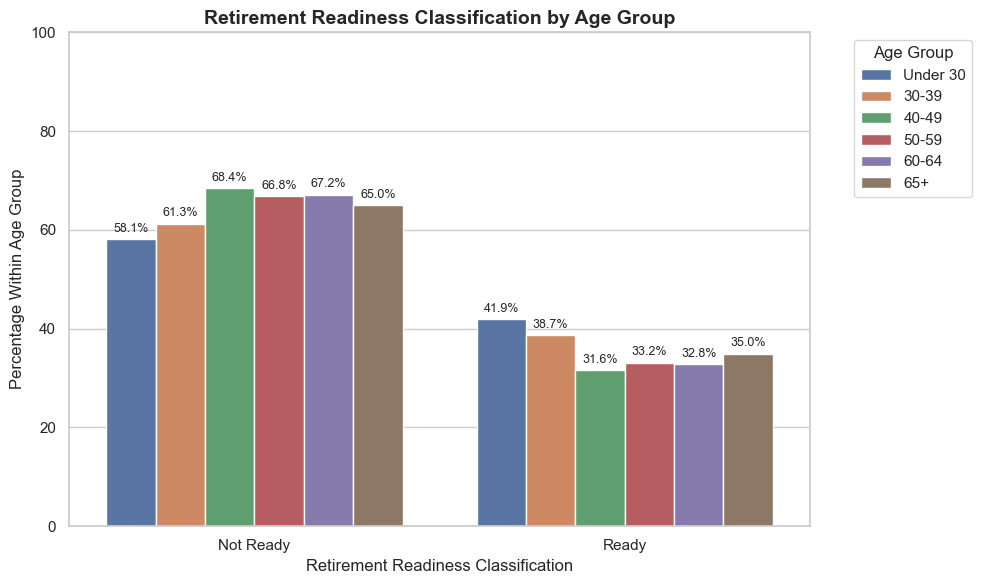

In [30]:
age_order = ["Under 30", "30-39", "40-49", "50-59", "60-64", "65+"]

plot_df = df.copy()

plot_df["RET_READY_LABEL"] = plot_df["RET_READY"].map({
    0: "Not Ready",
    1: "Ready"
})

plot_df["AGE_GROUP"] = pd.Categorical(
    plot_df["AGE_GROUP"],
    categories=age_order,
    ordered=True
)

ready_age_pct = (
    plot_df
    .groupby(["AGE_GROUP", "RET_READY_LABEL"], observed=False)
    .size()
    .reset_index(name="count")
)

ready_age_pct["percent"] = (
    ready_age_pct["count"] /
    ready_age_pct.groupby("AGE_GROUP")["count"].transform("sum") * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=ready_age_pct,
    x="RET_READY_LABEL",
    y="percent",
    hue="AGE_GROUP",
    hue_order=age_order,
    order=["Not Ready", "Ready"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title("Retirement Readiness Classification by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Retirement Readiness Classification")
plt.ylabel("Percentage Within Age Group")
plt.ylim(0, 100)
plt.legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

visualization 2

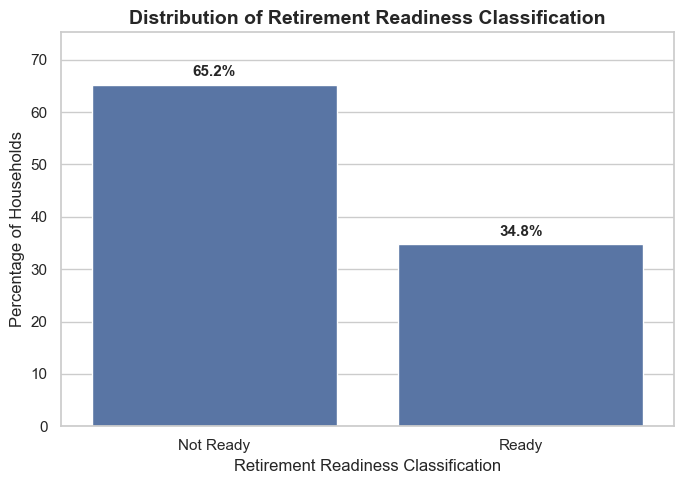

In [31]:
ready_pct = (
    plot_df["RET_READY_LABEL"]
    .value_counts(normalize=True)
    .reindex(["Not Ready", "Ready"]) * 100
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=ready_pct.index,
    y=ready_pct.values
)

for i, value in enumerate(ready_pct.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Distribution of Retirement Readiness Classification", fontsize=14, fontweight="bold")
plt.xlabel("Retirement Readiness Classification")
plt.ylabel("Percentage of Households")
plt.ylim(0, max(ready_pct.values) + 10)

plt.tight_layout()
plt.show()

Visualization 3

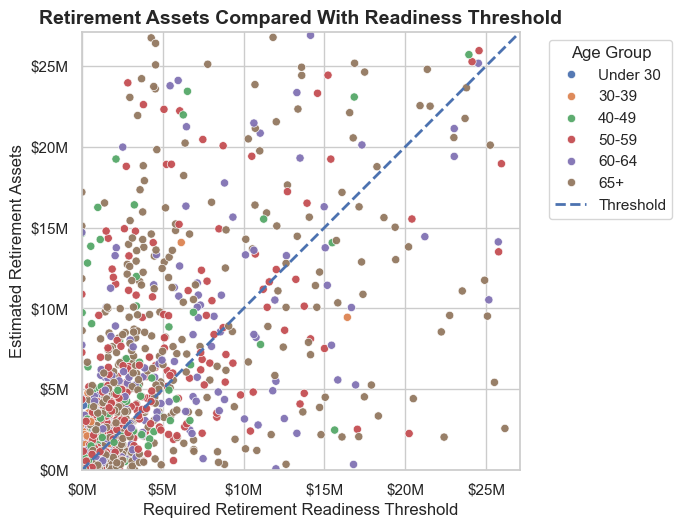

In [39]:
plot_df = df.copy()

# Sort age groups from youngest to oldest
age_order = ["Under 30", "30-39", "40-49", "50-59", "60-64", "65+"]

plot_df["AGE_GROUP"] = pd.Categorical(
    plot_df["AGE_GROUP"],
    categories=age_order,
    ordered=True
)

# Create threshold if not already saved
plot_df["REQUIRED_THRESHOLD"] = plot_df["INCOME_RAW_EST"] * plot_df["RET_MULTIPLIER"]

# Keep valid values
plot_df = plot_df[
    (plot_df["RET_ASSETS_RAW_EST"] >= 0) &
    (plot_df["REQUIRED_THRESHOLD"] >= 0)
].dropna(subset=["RET_ASSETS_RAW_EST", "REQUIRED_THRESHOLD", "AGE_GROUP"])

# Cap outliers for visualization only
cap_value = max(
    plot_df["REQUIRED_THRESHOLD"].quantile(0.95),
    plot_df["RET_ASSETS_RAW_EST"].quantile(0.95)
)

plot_df_viz = plot_df[
    (plot_df["REQUIRED_THRESHOLD"] <= cap_value) &
    (plot_df["RET_ASSETS_RAW_EST"] <= cap_value)
].copy()

# Square-shaped graph
plt.figure(figsize=(7, 7))

ax = sns.scatterplot(
    data=plot_df_viz,
    x="REQUIRED_THRESHOLD",
    y="RET_ASSETS_RAW_EST",
    hue="AGE_GROUP",
    hue_order=age_order,
    alpha=0.95,
    s=35
)

# Diagonal readiness line
plt.plot(
    [0, cap_value],
    [0, cap_value],
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlim(0, cap_value)
plt.ylim(0, cap_value)
ax.set_aspect("equal", adjustable="box")

# Format axes in millions
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"${y/1_000_000:.0f}M"))

plt.title("Retirement Assets Compared With Readiness Threshold", fontsize=14, fontweight="bold")
plt.xlabel("Required Retirement Readiness Threshold")
plt.ylabel("Estimated Retirement Assets")
plt.legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show() 

Visualization 4 (slide 6)

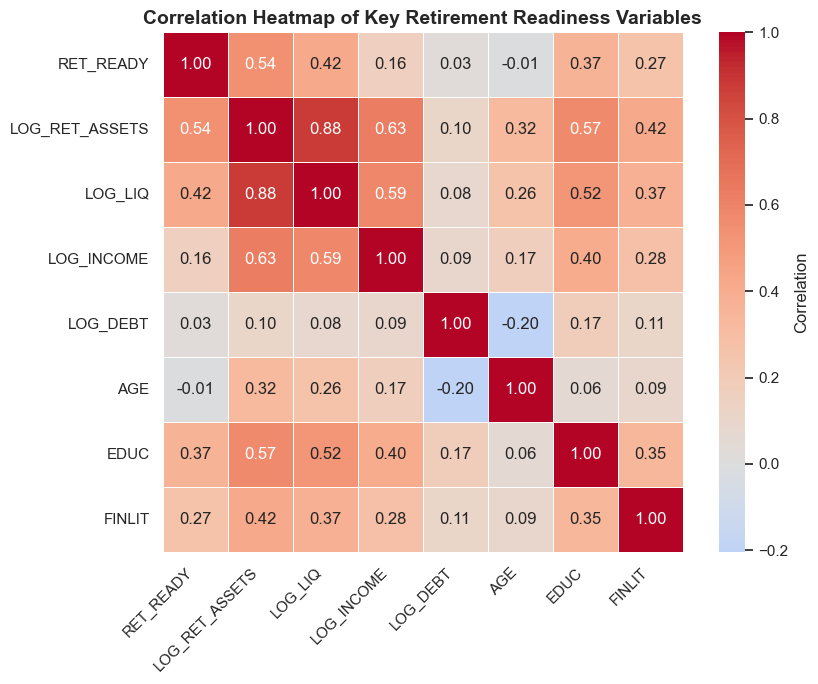

In [40]:
plot_df = df.copy()

if "REQUIRED_THRESHOLD" not in plot_df.columns:
    plot_df["REQUIRED_THRESHOLD"] = plot_df["INCOME_RAW_EST"] * plot_df["RET_MULTIPLIER"]

slide_corr_vars = [
    "RET_READY",
    "LOG_RET_ASSETS",
    "LOG_FIN",
    "LOG_LIQ",
    "LOG_INCOME",
    "LOG_DEBT",
    "AGE",
    "EDUC",
    "FINLIT"
]

slide_corr_vars = [col for col in slide_corr_vars if col in plot_df.columns]

corr_matrix = plot_df[slide_corr_vars].corr()

plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap of Key Retirement Readiness Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()